# STEP 1 EDA

In [29]:

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, classification_report, confusion_matrix, average_precision_score

from imblearn.over_sampling import SMOTE
import xgboost as xgb
from scipy import stats


Ranges were treated as dates: For example: 1-5 was 5th Jan 2026, Fix that at source

In [30]:
import pandas as pd

# fix for Excel date corruption in range columns

def fix_range_cell(x):

    s = str(x).strip()

    # regex check if it looks like a date (YYYY-MM-DD format)

    if pd.Series([s]).str.match(r"^\d{4}-\d{2}-\d{2}").iloc[0]:
        t = pd.to_datetime(s, errors="coerce")
        if pd.notna(t):
            return f"{t.month}-{t.day}"

    return s

# apply the converter to all range columns that might be affected
range_columns_to_fix = [
    'DATA_ANALYTICS_EMPLOYEES_RANGE',
    'ENGINEERING_EMPLOYEES_RANGE', 
    'FINANCE_EMPLOYEES_RANGE',
    'MARKETING_EMPLOYEES_RANGE', 
    'OPEN_JOB_POSTS_RANGE',
]

converters = {col: fix_range_cell for col in range_columns_to_fix}


train = pd.read_excel(   r"C:\Users\Advait Shinde\AgenticAIFrameworks\sf_ml_th\DS_Sample_Data.xlsx",
                      sheet_name='train',
                      converters=converters)

test = pd.read_excel(   r"C:\Users\Advait Shinde\AgenticAIFrameworks\sf_ml_th\DS_Sample_Data.xlsx",
                     sheet_name='test',
                     converters=converters)


In [31]:
print ( train.info() )
print ( test.info() )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   DATASET                            10000 non-null  object 
 1   TARGET                             10000 non-null  int64  
 2   ACCOUNT_ID                         10000 non-null  object 
 3   SALES_GEO                          10000 non-null  object 
 4   PRODUCT_FIT_SCORE                  10000 non-null  int64  
 5   DEAL_COMPLEXITY                    10000 non-null  object 
 6   HAS_INTERNAL_CHAMPION              10000 non-null  int64  
 7   ENGAGEMENT_SCORE                   10000 non-null  int64  
 8   REVENUE_RANGE                      10000 non-null  object 
 9   EMPLOYEE_COUNT                     10000 non-null  object 
 10  DATA_ANALYTICS_EMPLOYEES_RANGE     10000 non-null  object 
 11  ENGINEERING_EMPLOYEES_RANGE        10000 non-null  obje

In [32]:
train

,DATASET,TARGET,ACCOUNT_ID,SALES_GEO,PRODUCT_FIT_SCORE,DEAL_COMPLEXITY,HAS_INTERNAL_CHAMPION,ENGAGEMENT_SCORE,REVENUE_RANGE,EMPLOYEE_COUNT,...,MARKETING_EMPLOYEES_RANGE,OPEN_JOB_POSTS_RANGE,ESTIMATED_MONTHLY_IT_SPEND_RANGE,LINKEDIN_FOLLOWERS_RANGE,PUBLIC_PRIVATE_COMPANY,INDUSTRY,IS_VALID_WEBSITE,IS_USING_CLOUD_TECHNOLOGY,HAS_OFFICES_IN_MULTIPLE_LOCATIONS,LINKED_FOLLOWER_RANGE
0,train,1,46f19851053b146305d72bfbe5c4f62de32cd2941dc2d5...,APJ,68,Low,0,62,$10M-$50M,500-999,...,50-199,21-50,<$10K,<1K,Unknown,Unknown,True,1.0,0.0,<1K
1,train,1,52a1c89b31df676fed6168afbbbf699ddfb1f286df6857...,Americas,36,Medium,1,42,<$10M,<10,...,0,0,<$10K,<1K,Unknown,Unknown,True,0.0,0.0,<1K
2,train,1,26e0f5374b1faba5bb972a98965b88ec083e58dad3aba5...,APJ,50,Low,0,82,$50M-$100M,500-999,...,10-49,1-5,$50K-$100K,<1K,Privately owned,Financial Services,True,1.0,0.0,<1K
3,train,1,1fa9d424f1576e19a30999af8458a461e9d94dbb7ca498...,Americas,44,Low,1,73,$250M-$500M,1K-4.9K,...,10-49,21-50,$10K-$50K,10K-49.9K,Unknown,Consulting & Professional Services,True,1.0,1.0,10K-49.9K
4,train,1,94a39f77f4819fcdf6856e0b347a302ef07a90913316d1...,APJ,81,Medium,0,69,>$1B,5K-9.9K,...,10-49,0,$100K-$250K,<1K,Unknown,Retail & Consumer Goods,True,1.0,0.0,<1K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,train,0,2d9dd802fb09197c2a0fb1856485dfbfc762ec8007af8b...,EMEA,66,High,0,65,<$10M,<10,...,0,0,<$10K,<1K,Unknown,Technology,True,0.0,0.0,<1K
9996,train,0,c72f2ace7b8b8993cf31949ebdd12491436274d0891af9...,Americas,32,Medium,1,48,<$10M,10-49,...,0,0,$10K-$50K,<1K,Unknown,Technology,False,0.0,NaN,<1K
9997,train,0,6c99ea9f431faec755bc4eab05cdb6feb4387d255a669a...,APJ,71,Medium,1,58,$250M-$500M,5K-9.9K,...,50-199,0,$10K-$50K,<1K,Unknown,Manufacturing & Industrial,True,0.0,0.0,<1K
9998,train,0,8d3631cfc20f3203aea15b3ca5fd7069aceffe483d737a...,Americas,77,Low,0,43,<$10M,<10,...,0,0,<$10K,<1K,Unknown,Retail & Consumer Goods,True,0.0,0.0,<1K


Class 0 (Did NOT engage):  9000
Class 1 (Engaged):  1000


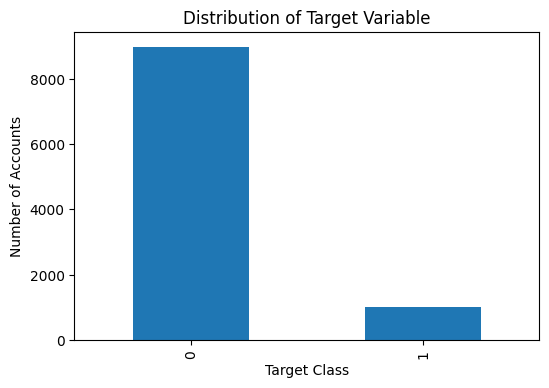

missing values: IS_USING_CLOUD_TECHNOLOGY            589
HAS_OFFICES_IN_MULTIPLE_LOCATIONS    785
dtype: int64


In [33]:
target_counts = train['TARGET'].value_counts()
target_pcts = train['TARGET'].value_counts(normalize=True)

print( "Class 0 (Did NOT engage): ", target_counts[0] )
print( "Class 1 (Engaged): ", target_counts[1]  )


#  target distribution

# count  plot
plt.figure(figsize=(6,4))

target_counts.plot(kind='bar' )
plt.title('Distribution of Target Variable')
plt.xlabel('Target Class')
plt.ylabel('Number of Accounts')


plt.show()

missing = train.isnull().sum()
print ( "missing values:", missing[missing > 0] )



**Use business logic here :**

- If no information on cloud: Assume they have it ( dont want to lose a potential customer)
- offices in multiple locations ( assume 1 location)

In [34]:
# imputation to TRAIN
train['IS_USING_CLOUD_TECHNOLOGY'] = train['IS_USING_CLOUD_TECHNOLOGY'].fillna(1)
train['HAS_OFFICES_IN_MULTIPLE_LOCATIONS'] = train['HAS_OFFICES_IN_MULTIPLE_LOCATIONS'].fillna(1)

# same imputation to TEST
test['IS_USING_CLOUD_TECHNOLOGY'] = test['IS_USING_CLOUD_TECHNOLOGY'].fillna(1)
test['HAS_OFFICES_IN_MULTIPLE_LOCATIONS'] = test['HAS_OFFICES_IN_MULTIPLE_LOCATIONS'].fillna(1)


In [35]:
missing = train.isnull().sum()
print ( "missing values:", missing[missing > 0] )

missing values: Series([], dtype: int64)


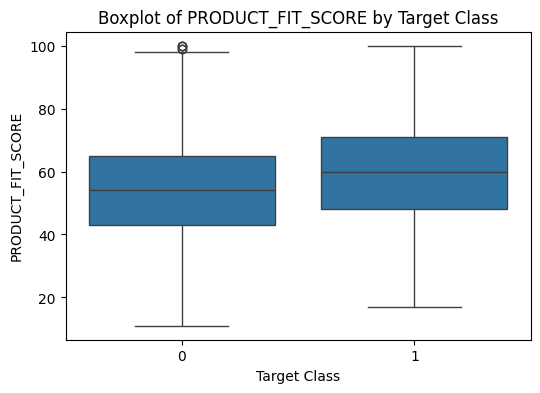

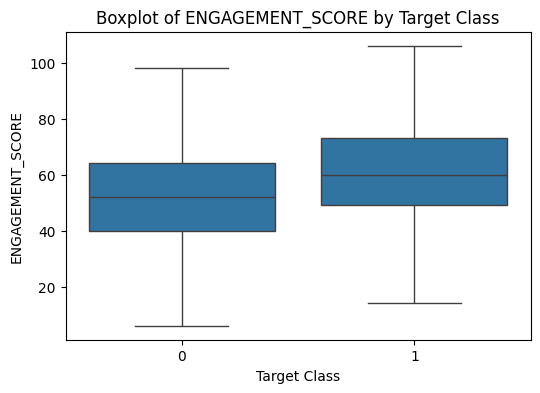

In [36]:
# outlier detection boxplots for numeric features

numeric_features = ['PRODUCT_FIT_SCORE', 'ENGAGEMENT_SCORE']

# plot boxplots
for feature in numeric_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='TARGET', y=feature, data=train)
    plt.title(f'Boxplot of {feature} by Target Class')
    plt.xlabel('Target Class')
    plt.ylabel(feature)
    plt.show()


Correlation 

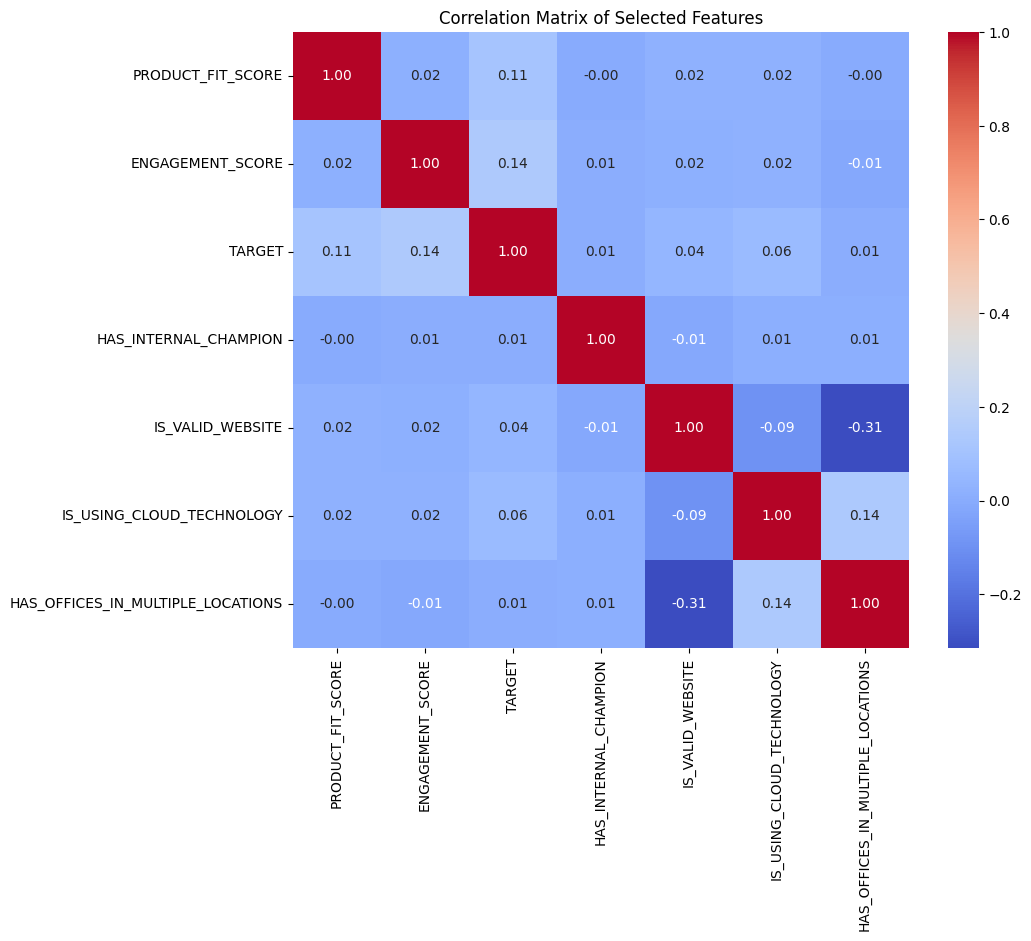

In [37]:
# Select numeric and binary features for correlation
numeric_cols = ['PRODUCT_FIT_SCORE', 'ENGAGEMENT_SCORE', 'TARGET']
binary_cols = ['HAS_INTERNAL_CHAMPION', 'IS_VALID_WEBSITE', 
               'IS_USING_CLOUD_TECHNOLOGY', 'HAS_OFFICES_IN_MULTIPLE_LOCATIONS']

correlation_features = numeric_cols + binary_cols

# Calculate correlation matrix
corr_matrix = train[correlation_features].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Selected Features')
plt.show()

Insights

- Engagement Score and Product fit score are strong predictors
- No high correlations found - features are independent, important and contribute to the target prediction
- The binary features are weak predictors individually.

Handling Range Features

- Examining all our range features and creating ordinal mappings that respect the natural ordering (e.g., "<10" < "10-49" < "50-199").
- Clean + map at the same time

In [38]:

import re

def smart_ordinal_encode(series):
    """
    Automatically encode range values in proper ordinal order.
    Uses AVERAGE of ranges for better representation.
    Handles formats like: '0', '1-9', '10-49', '<10', '>500', '$10M-$50M', etc.
    """
    unique_vals = series.dropna().unique()
    
    def extract_numeric_value(val):
        """Extract numeric value for sorting ranges - uses AVERAGE for ranges"""
        val_str = str(val).strip()
        
        # handle= '0' explicitly
        if val_str == '0':
            return 0
        
        # remove currency symbols and units
        val_clean = val_str.replace('$', '').replace(',', '')
        
        # handle 'K', 'M', 'B' multipliers

        multiplier = 1
        if 'K' in val_clean.upper():
            multiplier = 1000
            val_clean = val_clean.upper().replace('K', '')
        elif 'M' in val_clean.upper():
            multiplier = 1000000
            val_clean = val_clean.upper().replace('M', '')
        elif 'B' in val_clean.upper():
            multiplier = 1000000000
            val_clean = val_clean.upper().replace('B', '')
        
        # extract numbers using regex
        numbers = re.findall(r'\d+\.?\d*', val_clean)
        
        if not numbers:
            return 0
        
        # convert to floats and apply multiplier
        nums = [float(n) * multiplier for n in numbers]
        
        #  ranges like '10-49', take the AVERAGE
        if len(nums) >= 2:
            avg_val = (nums[0] + nums[1]) / 2
        else:
            avg_val = nums[0]
        
        #  for '<' (use value as upper bound, assume lower is 0)
        if val_str.startswith('<'):
            avg_val = avg_val / 2  

        # for '>' or '>=', use the number 
        elif val_str.startswith('>'):
            avg_val = avg_val                      # respecting upper bound as it can cause serious outliers

        elif val_str.startswith('>='):
            avg_val = avg_val 
        
        return avg_val
    
    # Create sorted mapping
    sorted_vals = sorted(unique_vals, key=extract_numeric_value)
    ordinal_map = {val: idx for idx, val in enumerate(sorted_vals)}
    
    # Apply mapping
    return series.map(ordinal_map), ordinal_map


range_features = [
    'EMPLOYEE_COUNT',
    'REVENUE_RANGE',
    'DATA_ANALYTICS_EMPLOYEES_RANGE',
    'ENGINEERING_EMPLOYEES_RANGE',
    'FINANCE_EMPLOYEES_RANGE',
    'MARKETING_EMPLOYEES_RANGE',
    'OPEN_JOB_POSTS_RANGE',
    'ESTIMATED_MONTHLY_IT_SPEND_RANGE',
    'LINKEDIN_FOLLOWERS_RANGE'
]

# Store mappings for test data
all_mappings = {}

for feature in range_features:
    print(f"\n{feature}:")
    
    # Encode train
    train[feature + '_ENCODED'], mapping = smart_ordinal_encode(train[feature])
    all_mappings[feature] = mapping
    
    # Encode test (using same mapping)
    test[feature + '_ENCODED'] = test[feature].map(mapping)
    
    # Check for unmapped values in test
    unmapped = test[test[feature + '_ENCODED'].isna()][feature].unique()
    if len(unmapped) > 0:
        print(f"   WARNING: Test has unmapped values: {unmapped}")
    
    # Show sample mapping
    print(f"  Ordinal mapping ({len(mapping)} levels):")
    for val, rank in sorted(mapping.items(), key=lambda x: x[1])[:5]:  # Show first 5
        count = (train[feature] == val).sum()
        print(f"    '{val}' → {rank} (n={count})")
    



EMPLOYEE_COUNT:
  Ordinal mapping (8 levels):
    '<10' → 0 (n=1859)
    '10-49' → 1 (n=2281)
    '50-199' → 2 (n=2017)
    '200-499' → 3 (n=1064)
    '500-999' → 4 (n=711)

REVENUE_RANGE:
  Ordinal mapping (7 levels):
    '<$10M' → 0 (n=5901)
    '$10M-$50M' → 1 (n=1508)
    '$50M-$100M' → 2 (n=571)
    '$100M-$250M' → 3 (n=618)
    '$500M-$1B' → 4 (n=310)

DATA_ANALYTICS_EMPLOYEES_RANGE:
  Ordinal mapping (8 levels):
    '0' → 0 (n=5244)
    '1-9' → 1 (n=3181)
    '10-49' → 2 (n=945)
    '50-199' → 3 (n=333)
    '200-499' → 4 (n=150)

ENGINEERING_EMPLOYEES_RANGE:
  Ordinal mapping (8 levels):
    '0' → 0 (n=3410)
    '1-9' → 1 (n=3199)
    '10-49' → 2 (n=1946)
    '50-199' → 3 (n=775)
    '200-499' → 4 (n=273)

FINANCE_EMPLOYEES_RANGE:
  Ordinal mapping (8 levels):
    '0' → 0 (n=4493)
    '1-9' → 1 (n=3068)
    '10-49' → 2 (n=1417)
    '50-199' → 3 (n=584)
    '200-499' → 4 (n=181)

MARKETING_EMPLOYEES_RANGE:
  Ordinal mapping (8 levels):
    '0' → 0 (n=4165)
    '1-9' → 1 (n=3555)

The classes are nearly continuous, so this ordinal ranking works

Encoding categorical features 
- (SALES_GEO, DEAL_COMPLEXITY, PUBLIC_PRIVATE_COMPANY, INDUSTRY) 

In [39]:
categorical_features = ['SALES_GEO', 'DEAL_COMPLEXITY', 'PUBLIC_PRIVATE_COMPANY', 'INDUSTRY']

for feature in categorical_features:
    n_unique = train[feature].nunique()
    print(f"\n{feature}: {n_unique} unique vals")


SALES_GEO: 3 unique vals

DEAL_COMPLEXITY: 3 unique vals

PUBLIC_PRIVATE_COMPANY: 3 unique vals

INDUSTRY: 11 unique vals


Choose one-hot encoding for first 3 features
Choose label encoding for INDUSTRY

In [40]:
# one hot encode categorical features SALES_GEO, DEAL_COMPLEXITY, PUBLIC_PRIVATE_COMPANY
from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import LabelEncoder

#  categorical features
onehot_features = ['SALES_GEO', 'DEAL_COMPLEXITY', 'PUBLIC_PRIVATE_COMPANY']
label_features = ['INDUSTRY']


le = LabelEncoder()
train['INDUSTRY_ENCODED'] = le.fit_transform(train['INDUSTRY'])
test['INDUSTRY_ENCODED'] = test['INDUSTRY'].map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

train_encoded = pd.get_dummies(train, columns=onehot_features, drop_first=True) # dummy variable trap avoidance
test_encoded = pd.get_dummies(test, columns=onehot_features, drop_first=True )   # dummy variable trap avoidance

#  train columns EXCLUDING TARGET
train_cols_no_target = [col for col in train.columns if col != 'TARGET']

# Align test columns with train (excluding TARGET)
for col in train_cols_no_target:
    if col not in test.columns:
        test[col] = 0

#  use non-TARGET columns for alignment
test = test[[col for col in train.columns if col in test.columns]]

In [41]:
print ( train.columns.tolist() )

['DATASET', 'TARGET', 'ACCOUNT_ID', 'SALES_GEO', 'PRODUCT_FIT_SCORE', 'DEAL_COMPLEXITY', 'HAS_INTERNAL_CHAMPION', 'ENGAGEMENT_SCORE', 'REVENUE_RANGE', 'EMPLOYEE_COUNT', 'DATA_ANALYTICS_EMPLOYEES_RANGE', 'ENGINEERING_EMPLOYEES_RANGE', 'FINANCE_EMPLOYEES_RANGE', 'MARKETING_EMPLOYEES_RANGE', 'OPEN_JOB_POSTS_RANGE', 'ESTIMATED_MONTHLY_IT_SPEND_RANGE', 'LINKEDIN_FOLLOWERS_RANGE', 'PUBLIC_PRIVATE_COMPANY', 'INDUSTRY', 'IS_VALID_WEBSITE', 'IS_USING_CLOUD_TECHNOLOGY', 'HAS_OFFICES_IN_MULTIPLE_LOCATIONS', 'LINKED_FOLLOWER_RANGE', 'EMPLOYEE_COUNT_ENCODED', 'REVENUE_RANGE_ENCODED', 'DATA_ANALYTICS_EMPLOYEES_RANGE_ENCODED', 'ENGINEERING_EMPLOYEES_RANGE_ENCODED', 'FINANCE_EMPLOYEES_RANGE_ENCODED', 'MARKETING_EMPLOYEES_RANGE_ENCODED', 'OPEN_JOB_POSTS_RANGE_ENCODED', 'ESTIMATED_MONTHLY_IT_SPEND_RANGE_ENCODED', 'LINKEDIN_FOLLOWERS_RANGE_ENCODED', 'INDUSTRY_ENCODED']


In [57]:
# drop original unencoded features

columns_to_drop = [
    'INDUSTRY',  # We have INDUSTRY_ENCODED
    'EMPLOYEE_COUNT',  # We have EMPLOYEE_COUNT_ENCODED
    'SALES_GEO'

    'REVENUE_RANGE',
    'DATA_ANALYTICS_EMPLOYEES_RANGE',           
    'ENGINEERING_EMPLOYEES_RANGE',
    'FINANCE_EMPLOYEES_RANGE',
    'MARKETING_EMPLOYEES_RANGE',                 # all range columns replaced by ENCODED versions
    'OPEN_JOB_POSTS_RANGE',
    'ESTIMATED_MONTHLY_IT_SPEND_RANGE',
    'LINKEDIN_FOLLOWERS_RANGE' ,

    'LINKED_FOLLOWER_RANGE',   # typo duplicate column
    'DATASET',  # irrelevant
   

]


In [58]:
# drop from both train and test
train = train.drop(columns=[col for col in columns_to_drop if col in train.columns])
test = test.drop(columns=[col for col in columns_to_drop if col in test.columns])

In [59]:
train.shape, test.shape

((10000, 21), (10000, 20))

sanity check to view data :D

In [60]:
train.to_excel( r"C:\Users\Advait Shinde\AgenticAIFrameworks\sf_ml_th\train_processed.xlsx", index=False )
test.to_excel( r"C:\Users\Advait Shinde\AgenticAIFrameworks\sf_ml_th\test_processed.xlsx", index=False )

In [61]:
print ( train.columns.tolist() )

['TARGET', 'ACCOUNT_ID', 'SALES_GEO', 'PRODUCT_FIT_SCORE', 'DEAL_COMPLEXITY', 'HAS_INTERNAL_CHAMPION', 'ENGAGEMENT_SCORE', 'PUBLIC_PRIVATE_COMPANY', 'IS_VALID_WEBSITE', 'IS_USING_CLOUD_TECHNOLOGY', 'HAS_OFFICES_IN_MULTIPLE_LOCATIONS', 'EMPLOYEE_COUNT_ENCODED', 'REVENUE_RANGE_ENCODED', 'DATA_ANALYTICS_EMPLOYEES_RANGE_ENCODED', 'ENGINEERING_EMPLOYEES_RANGE_ENCODED', 'FINANCE_EMPLOYEES_RANGE_ENCODED', 'MARKETING_EMPLOYEES_RANGE_ENCODED', 'OPEN_JOB_POSTS_RANGE_ENCODED', 'ESTIMATED_MONTHLY_IT_SPEND_RANGE_ENCODED', 'LINKEDIN_FOLLOWERS_RANGE_ENCODED', 'INDUSTRY_ENCODED']


In [62]:
feature_cols = [col for col in train.columns if col not in ['ACCOUNT_ID', 'TARGET']]
X = train[feature_cols]
y = train['TARGET']

print("   Total samples: ", len(X))
print("   Features:  ", len(feature_cols))
print("   Target distribution: ", y.value_counts().to_dict())

   Total samples:  10000
   Features:   19
   Target distribution:  {0: 9000, 1: 1000}


### Additional Feature Selection and Engineering After 1st Run

Set threshold and remove features that dont contribute

In [63]:
# Identify weak features (|correlation| < 0.05)
weak_threshold = 0.05
weak_features = correlations[abs(correlations) < weak_threshold].index.tolist()

In [64]:
train_enhanced = train.copy()
test_enhanced = test.copy()

In [65]:
interactions = [
    ('ENGAGEMENT_SCORE', 'EMPLOYEE_COUNT_ENCODED', 'engagement_x_size'),
   
    ('ENGAGEMENT_SCORE', 'REVENUE_RANGE_ENCODED', 'engagement_x_revenue'),

    ('PRODUCT_FIT_SCORE', 'PRODUCT_FIT_SCORE', 'product_score_squared'),
    
    ('ENGAGEMENT_SCORE', 'ENGAGEMENT_SCORE', 'engagement_squared'),
]

print("interaction features:")
for feat1, feat2, name in interactions:
    train_enhanced[name] = train_enhanced[feat1] * train_enhanced[feat2]
    test_enhanced[name] = test_enhanced[feat1] * test_enhanced[feat2]
    
    #  correlation of new feature
    new_corr = train_enhanced[[name, 'TARGET']].corr().iloc[0, 1]
    print(f"  {name:30s} = {feat1:25s} × {feat2:30s} | Correlation: {new_corr:.4f}")



interaction features:
  engagement_x_size              = ENGAGEMENT_SCORE          × EMPLOYEE_COUNT_ENCODED         | Correlation: 0.1495
  engagement_x_revenue           = ENGAGEMENT_SCORE          × REVENUE_RANGE_ENCODED          | Correlation: 0.1562
  product_score_squared          = PRODUCT_FIT_SCORE         × PRODUCT_FIT_SCORE              | Correlation: 0.1109
  engagement_squared             = ENGAGEMENT_SCORE          × ENGAGEMENT_SCORE               | Correlation: 0.1451


In [66]:
enhanced_feature_cols = [col for col in train_enhanced.columns if col not in ['ACCOUNT_ID', 'TARGET']]
X_enhanced = train_enhanced[enhanced_feature_cols]
y_enhanced = train_enhanced['TARGET']

from sklearn.model_selection import StratifiedKFold, cross_val_score

# Still keep your train/val split for final evaluation
X_train_enh, X_val_enh, y_train_enh, y_val_enh = train_test_split(
    X_enhanced, y_enhanced, 
    test_size=0.2, 
    stratify=y_enhanced,
    random_state=42
)

Creating a stratified train-validation split (80-20) to preserve the class imbalance ratio in both sets
self note: Stratification ensures both train and validation sets have the same 9:1 class distribution. 

**Summary of EDA:**

- Excel Date Corruption Handling
- Duplicate Columns and Irrelevant Columns Handling
- Missing Values handle w business logic
- Range conversion to Ordinal encoding
- Encoding
- Outlier Check
- Correlation matrix to find correlated features

**Feature Engineering**
- Drop features with correlation < 0.05 (very weak predictors)
- Create interaction features (ENGAGEMENT_SCORE × EMPLOYEE_COUNT_ENCODED, etc.)

**Strategy to handle imbalance**
- stratification
- class weights


# STEP 2.1 Baseline Model Training

In [67]:

lr_model = LogisticRegression(
    class_weight='balanced',  # Handle imbalance
random_state=42,
max_iter=10000,
solver='saga'
)

lr_model.fit(X_train_enh, y_train_enh)

y_val_proba = lr_model.predict_proba(X_val_enh)[:, 1]  # Probability of class 1
y_val_pred = lr_model.predict(X_val_enh)

ValueError: could not convert string to float: 'EMEA'

In [43]:
roc_auc = roc_auc_score(y_val_enh, y_val_proba)
print("Validation ROC-AUC: ", roc_auc)


Validation ROC-AUC:  0.6725833333333333


In [44]:
print(classification_report(y_val_enh, y_val_pred, target_names=['Not Engaged (0)', 'Engaged (1)']))

                 precision    recall  f1-score   support

Not Engaged (0)       0.93      0.70      0.80      1800
    Engaged (1)       0.16      0.51      0.24       200

       accuracy                           0.68      2000
      macro avg       0.54      0.60      0.52      2000
   weighted avg       0.85      0.68      0.74      2000



Insights: 

- ROC-AUC : Slightly over randomly guessing


- The Precision Problem: 16% for Engaged Class

- When the model predicts "Engaged", it's wrong 82% of the time : Sales teams would waste massive effort on false positives.
 Only 18 out of 100 predicted "hot leads" are actually hot


Causes: 

- Non-Linear Relationships
- Imbalance causes undertraining of label with 18% accuracy.

**Why I'm choosing a Tree based model**

- capturing non linearity
- handling categorical labels better
- more generalization  (robust to noise)
- can handle class imbalance with weighted labels

# Step 2.2 Final Model: XGBoost

In [45]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix



n_class_0 = (y_train_enh == 0).sum()
n_class_1 = (y_train_enh == 1).sum()
scale_pos_weight = n_class_0 / n_class_1

enhanced_xgb = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    
    learning_rate=0.1,
    max_depth=3,
    min_child_weight=5,
    n_estimators=100,
    
    objective='binary:logistic',

    eval_metric='auc',
    random_state=42,
    
    tree_method='hist'
)

enhanced_xgb.fit(X_train_enh, y_train_enh)
y_val_proba_enh = enhanced_xgb.predict_proba(X_val_enh)[:, 1]
y_val_pred_enh = enhanced_xgb.predict(X_val_enh)

roc_auc_enh = roc_auc_score(y_val_enh, y_val_proba_enh)
pr_auc_enh = average_precision_score(y_val_enh, y_val_proba_enh)

In [46]:
print("XGBoost Validation ROC-AUC: ", roc_auc_enh)


XGBoost Validation ROC-AUC:  0.7301680555555555


In [47]:
print("classification_report:")
print(classification_report(y_val_enh, y_val_pred_enh, target_names=['Not Engaged (0)', 'Engaged (1)']))

classification_report:
                 precision    recall  f1-score   support

Not Engaged (0)       0.95      0.70      0.80      1800
    Engaged (1)       0.19      0.64      0.29       200

       accuracy                           0.69      2000
      macro avg       0.57      0.67      0.55      2000
   weighted avg       0.87      0.69      0.75      2000



Takeaways: 


- Logistic Regression: 0.67 ROC-AUC

- XGBoost (tuned): 0.73 ROC-AUC

- Engagement Score being the best feature via correlation still weakly predicts engagement
- Other features having low correlation
- Some features dont correlate
- Class imbalance
- Model is unable to find decision boundaries: Identical companies have variable engagements


# Scoring and Ranking

In [51]:
import numpy as np

feature_cols = [col for col in train.columns if col not in ['ACCOUNT_ID', 'TARGET']]
# Ensure test_features has the same columns as X_train_enh
test_features = test_enhanced[X_train_enh.columns]

test_probabilities = enhanced_xgb.predict_proba(test_features)[:, 1]


print(f"\nProbability Distribution:")
print(f"  Min:    {test_probabilities.min():.4f}")
print(f"  25th:   {np.percentile(test_probabilities, 25):.4f}")
print(f"  Median: {np.percentile(test_probabilities, 50):.4f}")
print(f"  75th:   {np.percentile(test_probabilities, 75):.4f}")
print(f"  Max:    {test_probabilities.max():.4f}")
print(f"  Mean:   {test_probabilities.mean():.4f}")





Probability Distribution:
  Min:    0.0047
  25th:   0.2341
  Median: 0.3772
  75th:   0.5470
  Max:    0.9817
  Mean:   0.3940


**WHY PERCENTILE-BASED SCORING?**
1. Intuitive: Score of 80 = "Better than 80% of accounts"
2. Distribution: Ensures scores spread across full 0-100 range
3. Relative: Accounts are ranked against each other, not absolute thresholds
4. Actionable: Sales can easily prioritize "top 10%" or "top 25%"

**INTERPRETATION:**
- APS 90-100: Top 10% of accounts (Highest Priority)
- APS 75-89:  Next 15% (High Priority)  
- APS 50-74:  Middle 25% (Medium Priority)
- APS 25-49:  Lower-middle 25% (Low-Medium Priority)
- APS 0-24:   Bottom 25% (Low Priority)

In [52]:
from scipy.stats import rankdata

aps_scores = (rankdata(test_probabilities, method='average') / len(test_probabilities)) * 100

def assign_priority_tier(score):
    """Assign business priority tier based on APS score"""
    if score >= 90:
        return 'Tier 1: Hot Leads'
    elif score >= 75:
        return 'Tier 2: Warm Leads'
    elif score >= 50:
        return 'Tier 3: Qualified Prospects'
    elif score >= 25:
        return 'Tier 4: Nurture Prospects'
    else:
        return 'Tier 5: Low Priority'

def assign_action_recommendation(score):
    """Recommend action based on APS score"""
    if score >= 90:
        return 'IMMEDIATE OUTREACH - High-touch sales engagement'
    elif score >= 75:
        return 'PRIORITIZE - Schedule demos, personalized campaigns'
    elif score >= 50:
        return 'QUALIFY - Targeted content, webinars, case studies'
    elif score >= 25:
        return 'NURTURE - Automated drip campaigns, newsletters'
    else:
        return 'MONITOR - Minimal effort, periodic check-ins'

# create results DataFrame
results_df = pd.DataFrame({
    'ACCOUNT_ID': test['ACCOUNT_ID'],
    'PREDICTED_PROBABILITY': test_probabilities,
    'APS_SCORE': aps_scores
})

#  business tiers and actions
results_df['PRIORITY_TIER'] = results_df['APS_SCORE'].apply(assign_priority_tier)
results_df['RECOMMENDED_ACTION'] = results_df['APS_SCORE'].apply(assign_action_recommendation)

# sort by priority (highest first)
results_df = results_df.sort_values('APS_SCORE', ascending=False).reset_index(drop=True)

In [53]:
tier_summary = results_df['PRIORITY_TIER'].value_counts().sort_index()
for tier, count in tier_summary.items():
    pct = (count / len(results_df)) * 100
    print(f"{tier:30s}: {count:5,} accounts ({pct:5.1f}%)")

Tier 1: Hot Leads             : 1,001 accounts ( 10.0%)
Tier 2: Warm Leads            : 1,499 accounts ( 15.0%)
Tier 3: Qualified Prospects   : 2,501 accounts ( 25.0%)
Tier 4: Nurture Prospects     : 2,500 accounts ( 25.0%)
Tier 5: Low Priority          : 2,499 accounts ( 25.0%)


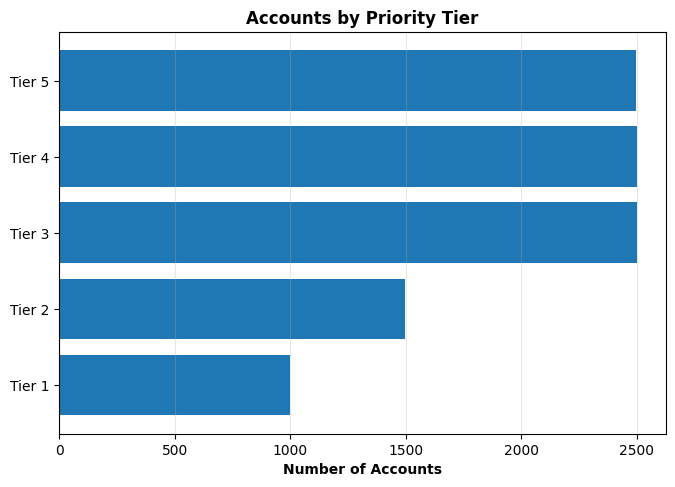

In [74]:
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
tier_counts = results_df['PRIORITY_TIER'].value_counts().sort_index()

bars = ax1.barh(range(len(tier_counts)), tier_counts.values)
ax1.set_yticks(range(len(tier_counts)))

ax1.set_yticklabels([t.split(':')[0] for t in tier_counts.index])
ax1.set_xlabel('Number of Accounts', fontweight='bold')
ax1.set_title('Accounts by Priority Tier', fontweight='bold', fontsize=12)
ax1.grid(axis='x', alpha=0.3)




In [75]:
output_file = 'snowflake_account_propensity_scores.csv'
results_df.to_csv(output_file, index=False)